## Import required libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, confusion_matrix

import nltk
import re
import string

from nltk.stem import PorterStemmer
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.tokenize import word_tokenize, sent_tokenize

from tensorflow.keras.preprocessing.text import one_hot, Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Embedding, Input, LSTM, Conv1D, MaxPool1D, Bidirectional
from tensorflow.keras.models import Model

import warnings
warnings.filterwarnings('ignore')

## Download required nltk data


In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

## Mount google drive and read CSV data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

realDf = pd.read_csv('/content/drive/MyDrive/MS-AIML/Data Analytics Capstone/Notebook/dataset/True.csv')
fakeDf = pd.read_csv('/content/drive/MyDrive/MS-AIML/Data Analytics Capstone/Notebook/dataset/Fake.csv')

In [ ]:
realDf.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [ ]:
fakeDf.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [ ]:
realDf['label'] = 1
fakeDf['label'] = 0

In [ ]:
df = pd.concat([realDf, fakeDf])
print("Shape of combined dataset = ",df.shape)

Shape of combined dataset =  (44898, 5)


In [ ]:
df["Article"] = df["title"] + df["text"]
df = df.loc[:,["Article","label"]]
df.head()

,Article,label
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1


In [ ]:
print("Shape:", df.shape)
df.head()

Shape: (44898, 2)


,Article,label
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1


In [ ]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Article  44898 non-null  object
 1   label    44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.0+ MB


,0
Article,0
label,0


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()
print("Shape:", df.shape)
df.head()

Duplicate rows: 5793
Shape: (39105, 2)


,Article,label
0,"As U.S. budget fight looms, Republicans flip t...",1
1,U.S. military to accept transgender recruits o...,1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,1
3,FBI Russia probe helped by Australian diplomat...,1
4,Trump wants Postal Service to charge 'much mor...,1


## Data Cleaning

In [ ]:
import re
import string

def clean_text(text, remove_stopwords=False, lemmatize=False, min_word_length=3):
    """
    Clean and preprocess text with optional stopword removal, lemmatization,
    and minimum word length filtering.

    Parameters:
        text (str): Input text
        remove_stopwords (bool): Whether to remove stopwords
        lemmatize (bool): Whether to apply lemmatization
        min_word_length (int): Minimum length of words to keep

    Returns:
        str: Cleaned text
    """

    # Basic cleaning
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags
    text = re.sub(r'\[.*?\]', '', text)  # Remove bracketed text
    text = re.sub(r'\w*\d\w*', '', text)  # Remove words with numbers
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation/special chars
    text = re.sub(r'\n', ' ', text)  # Replace newline with space
    text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace

    words = text.split()

    # Remove short words
    words = [word for word in words if len(word) >= min_word_length]

    # Optional: Stopword removal
    if remove_stopwords:
        try:
            from nltk.corpus import stopwords
            stop_words = set(stopwords.words('english'))
            words = [word for word in words if word not in stop_words]
        except:
            print("NLTK stopwords not found. Run: nltk.download('stopwords')")

    # Optional: Lemmatization
    if lemmatize:
        try:
            from nltk.stem import WordNetLemmatizer
            lemmatizer = WordNetLemmatizer()
            words = [lemmatizer.lemmatize(word) for word in words]
        except:
            print("WordNet not found. Run: nltk.download('wordnet')")

    return " ".join(words)

In [ ]:
df['Article'] = df['Article'].apply(
    lambda x: clean_text(x, remove_stopwords=True, lemmatize=True)
)

In [ ]:
df.head()

,Article,label
0,budget fight loom republican flip fiscal scrip...,1
1,military accept transgender recruit monday pen...,1
2,senior republican senator let mueller jobwashi...,1
3,fbi russia probe helped australian diplomat ti...,1
4,trump want postal service charge much amazon s...,1


## Visualise class distribution

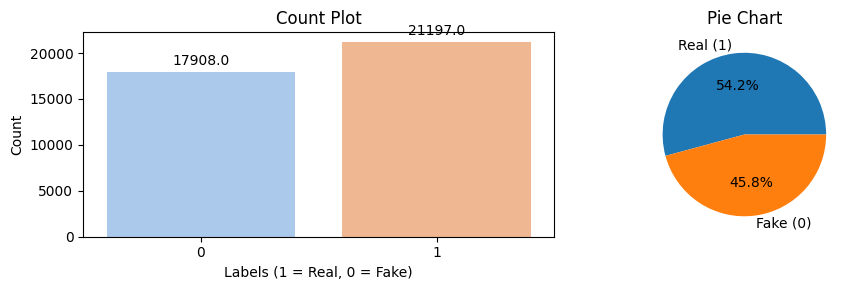

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.countplot(x='label', data=df, palette='pastel', ax=axes[0])

for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

axes[0].set_title('Count Plot')
axes[0].set_xlabel('Labels (1 = Real, 0 = Fake)')
axes[0].set_ylabel('Count')


counts = df['label'].value_counts()
labels = [f'Real ({i})' if i == 1 else f'Fake ({i})' for i in counts.index]
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%')
axes[1].set_title('Pie Chart')

plt.tight_layout()

plt.show()

## Top Discriminative Words in Real vs Fake News

In [ ]:
from collections import Counter

def get_top_words(text_series, n=30):
    all_words = " ".join(text_series).split()
    return Counter(all_words).most_common(n)

# Separate classes 1 - Real and 0 - Fake
real_text = df[df['label'] == 1]['Article']
fake_text = df[df['label'] == 0]['Article']


In [ ]:
# Get top words
real_words = get_top_words(real_text.values)
fake_words = get_top_words(fake_text.values)

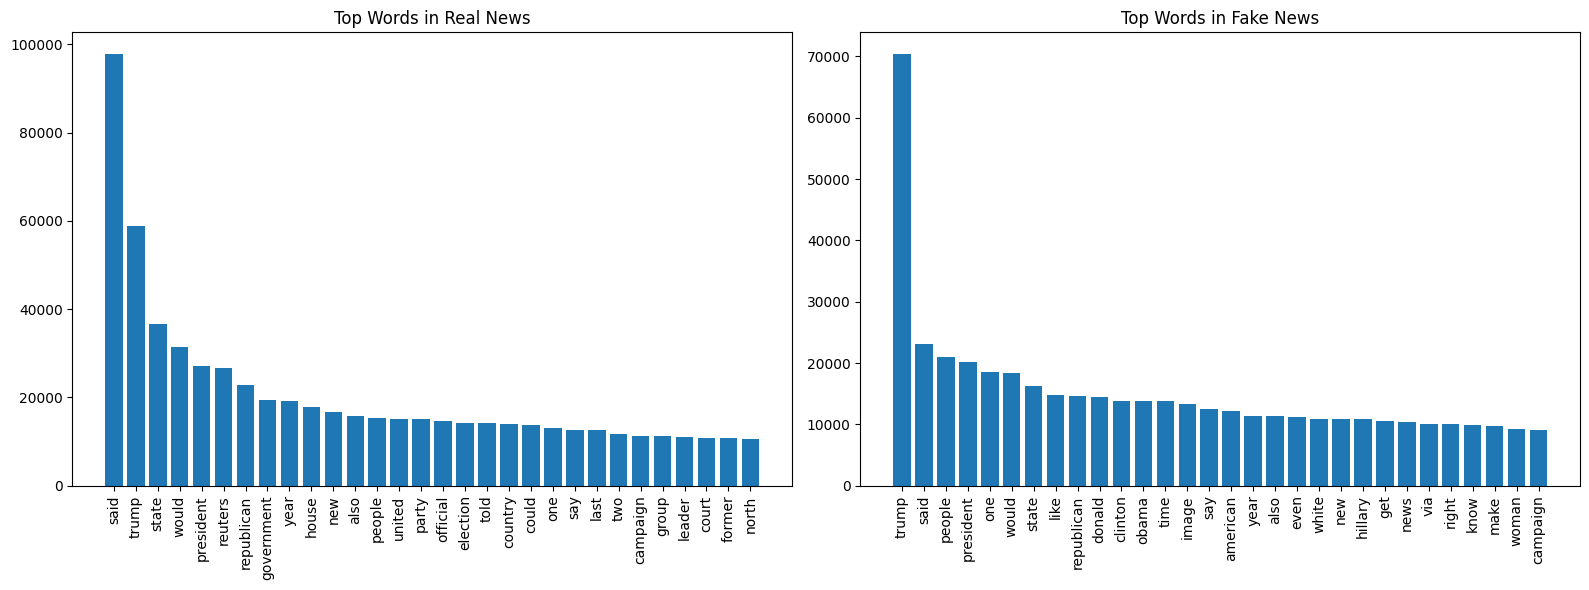

In [ ]:
# Convert to plotting format
real_words_df = dict(real_words)
fake_words_df = dict(fake_words)

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Real News Plot
axes[0].bar(real_words_df.keys(), real_words_df.values())
axes[0].set_title("Top Words in Real News")
axes[0].tick_params(axis='x', rotation=90)

# Fake News Plot
axes[1].bar(fake_words_df.keys(), fake_words_df.values())
axes[1].set_title("Top Words in Fake News")
axes[1].tick_params(axis='x', rotation=90)

# Adjust layout
plt.tight_layout()

# Show combined plot
plt.show()

## Most Frequent Terms Across Real and Fake News Articles

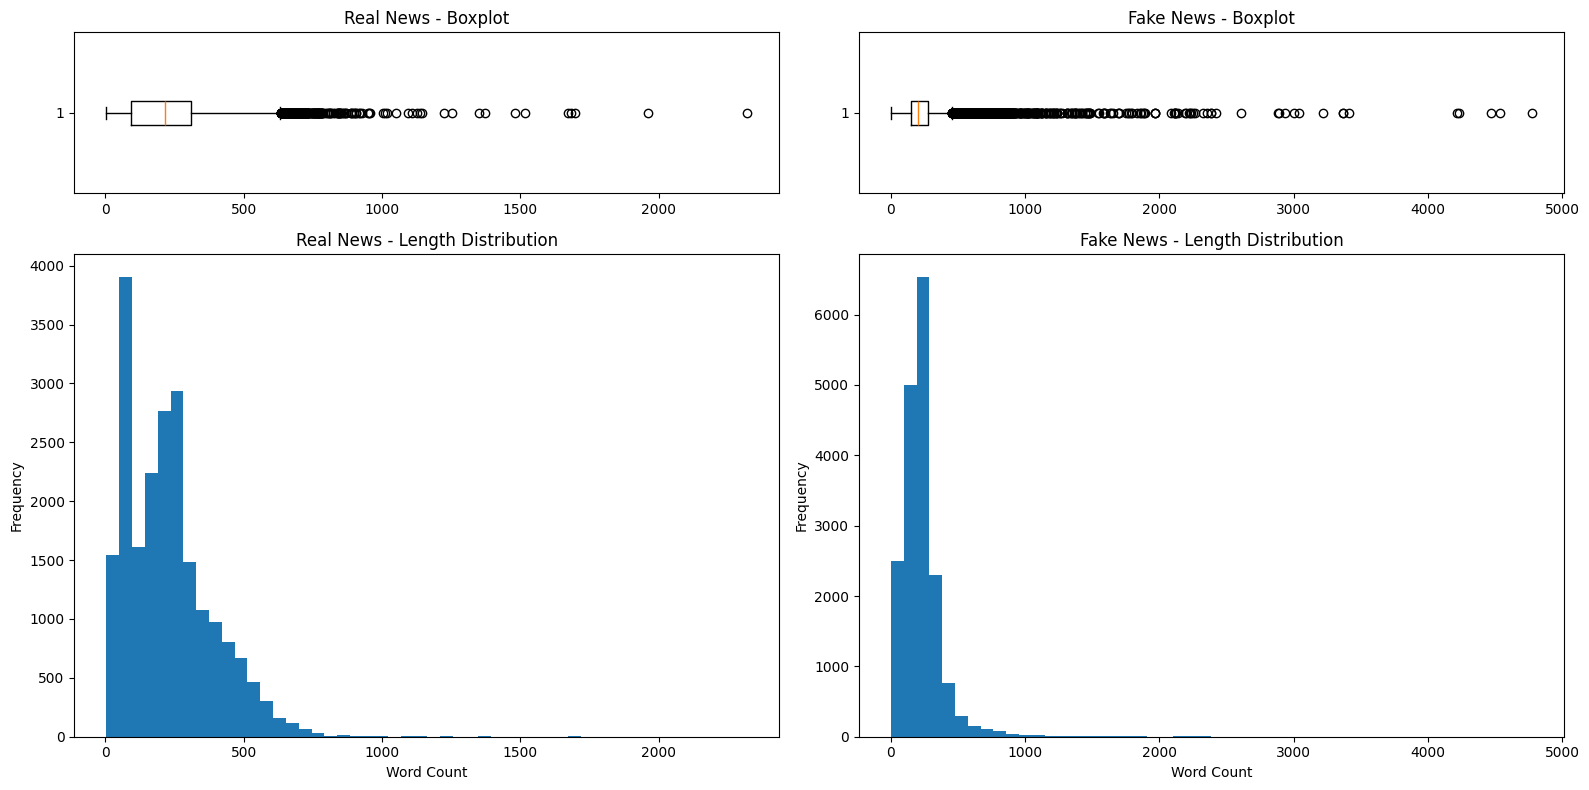

In [ ]:
import matplotlib.pyplot as plt

# Add text length column
df['text_length'] = df['Article'].apply(lambda x: len(x.split()))

# Create 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(16, 8),gridspec_kw={'height_ratios': [1, 3]})

# -------------------
# Real News
# -------------------

# Boxplot (top)
axes[0, 0].boxplot(df[df['label'] == 1]['text_length'], vert=False)
axes[0, 0].set_title("Real News - Boxplot")

# Histogram (bottom)
axes[1, 0].hist(df[df['label'] == 1]['text_length'], bins=50)
axes[1, 0].set_title("Real News - Length Distribution")
axes[1, 0].set_xlabel("Word Count")
axes[1, 0].set_ylabel("Frequency")

# -------------------
# Fake News
# -------------------

# Boxplot (top)
axes[0, 1].boxplot(df[df['label'] == 0]['text_length'], vert=False)
axes[0, 1].set_title("Fake News - Boxplot")

# Histogram (bottom)
axes[1, 1].hist(df[df['label'] == 0]['text_length'], bins=50)
axes[1, 1].set_title("Fake News - Length Distribution")
axes[1, 1].set_xlabel("Word Count")
axes[1, 1].set_ylabel("Frequency")

# Improve spacing
plt.tight_layout()
plt.show()

## WordCloud

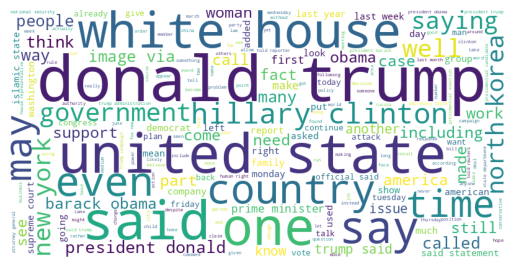

In [ ]:
from wordcloud import WordCloud

text = " ".join(df['Article'])

wc = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.imshow(wc)
plt.axis('off')
plt.show()

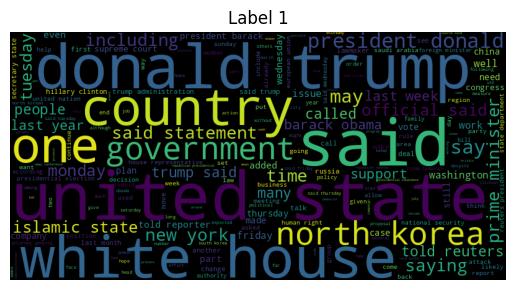

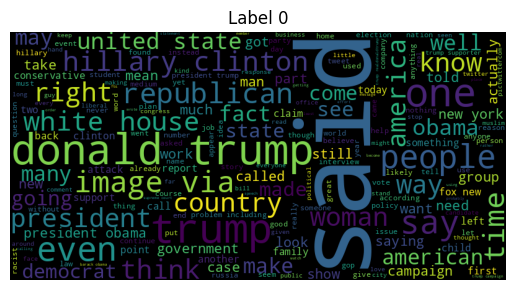

In [ ]:
for label in df['label'].unique():
    text = " ".join(df[df['label'] == label]['Article'])

    wc = WordCloud(width=800, height=400).generate(text)

    plt.imshow(wc)
    plt.axis('off')
    plt.title(f'Label {label}')
    plt.show()

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,2), max_features=20)
X = vectorizer.fit_transform(df['Article'])

print(vectorizer.get_feature_names_out())

['also' 'clinton' 'country' 'donald' 'donald trump' 'government' 'house'
 'new' 'one' 'people' 'president' 'republican' 'reuters' 'said' 'say'
 'state' 'time' 'trump' 'would' 'year']


## Model

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df['Article'], df['label'], test_size=0.2, random_state=48)

In [ ]:
y_train=y_train.astype('int')
y_test=y_test.astype('int')

In [ ]:
#LogisticRegression
pipe = Pipeline([('vect', CountVectorizer()),
                 ('tfidf', TfidfTransformer()),
                 ('model', LogisticRegression())])

Logisticmodel = pipe.fit(X_train, y_train)
prediction = Logisticmodel.predict(X_test)
print("accuracy: {}%".format(round(accuracy_score(y_test, prediction)*100,2)))
Logisticmodel_accuracy = round(accuracy_score(y_test, prediction)*100,2)

accuracy: 98.27%


In [ ]:
X_train.head()

,Article
5872,travel ban herald turbulent time africa chiefa...
20394,militant blast gun attack kill police egypt si...
2593,factbox trump soninlaw kushner detail contact ...
14969,detroit suburb elect first muslim majority cit...
427,factbox republican watch senate tax bill fight...


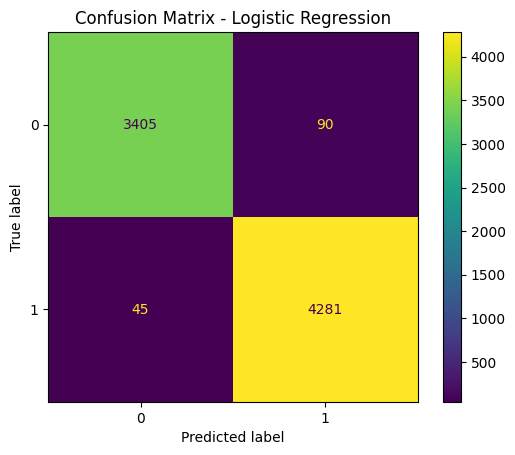

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      3495
           1       0.98      0.99      0.98      4326

    accuracy                           0.98      7821
   macro avg       0.98      0.98      0.98      7821
weighted avg       0.98      0.98      0.98      7821



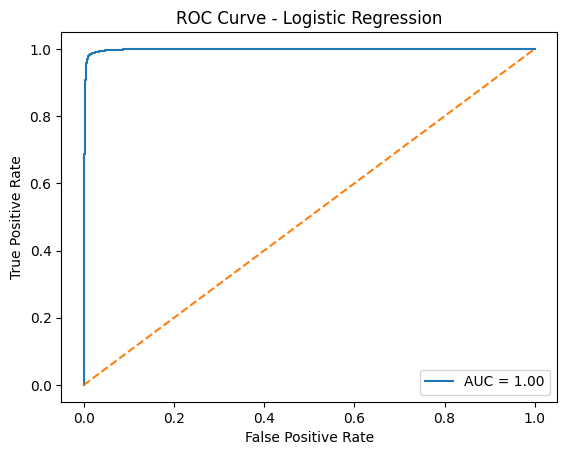

In [ ]:
from sklearn.metrics import roc_curve, auc

y_prob = Logisticmodel.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

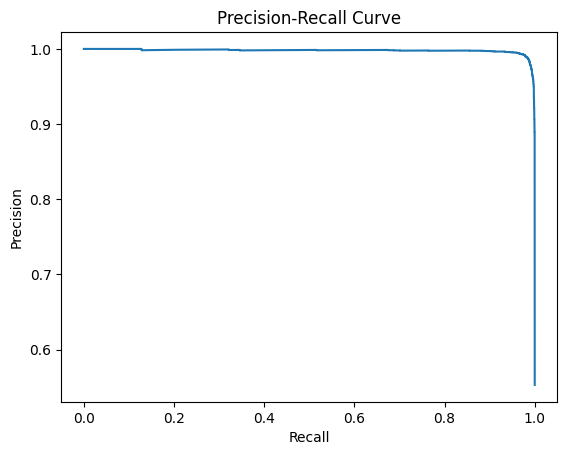

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Naive Bayes Model

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_pipe = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', MultinomialNB())
])

nb_model = nb_pipe.fit(X_train, y_train)
nb_pred = nb_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Naive Bayes Accuracy:", round(accuracy_score(y_test, nb_pred)*100,2))

Naive Bayes Accuracy: 93.08


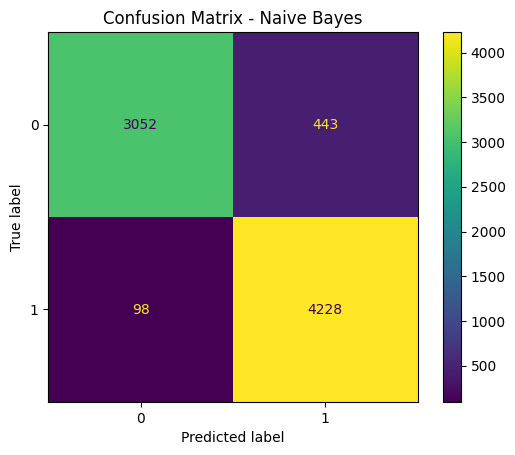

In [ ]:
cm_nb = confusion_matrix(y_test, nb_pred)

ConfusionMatrixDisplay(confusion_matrix=cm_nb).plot()
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

In [ ]:
print("Logistic Regression Accuracy:", Logisticmodel_accuracy)
print("Naive Bayes Accuracy:", round(accuracy_score(y_test, nb_pred)*100,2))

Logistic Regression Accuracy: 98.27
Naive Bayes Accuracy: 93.08


In [ ]:
from sklearn.svm import LinearSVC

svm_pipe = Pipeline([
    ('vect', CountVectorizer()),
    ('tfidf', TfidfTransformer()),
    ('model', LinearSVC())
])

svm_model = svm_pipe.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", round(accuracy_score(y_test, svm_pred)*100,2))

SVM Accuracy: 99.05
